In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

from utils.autocorrelation_per_state import autocorrelation_per_state # Import custom autoccorelation function

In [84]:
# Needed Columns for the Hypothesis testing
#data_needed = ["Order Date", "Category", "Revenue", "Shipping Address State", "tavg"]

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/grocery_data.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"])
groceries_df.set_index("Order Date", inplace=True)
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

In [85]:
#transactions_temp = transactions_temp[~transactions_temp["Shipping Address State"].isin(["AK", "HI", "PR", "DC", "I did not reside in the United States"])] # Remove Shipping addresses without temperature information

In [86]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    maxlag = 12    
    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [87]:
# List of states
states_list = groceries_df["Shipping Address State"].unique()

# Creating Filtered dataframe for Granger test
df_granger_grocerie = groceries_df[["Revenue", "tavg", "Shipping Address State"]]

df_granger_fashion = fashion_df[["Revenue", "tavg", "Shipping Address State"]]


## Granger Test Groceries: First order diff for Revenue - Temp no seasonality

In [88]:
state_p_values_grocerie = {}
#states_list = ["CA"]
for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state = df_one_state.iloc[365:, ]

        #Fist order Diff for Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff


        #df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)

        #df_one_state["Temp_SMA30"] = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)

        #df_granger_groceries= df_one_state.iloc[30:, ].copy() 

        #granger_matrix = grangers_causation_matrix(df_granger_groceries ,variables=["Revenue", "Temp_No_Season"])
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values_grocerie[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state AL temperature as a predictor has a p-value of: 0.3481
For the state AR temperature as a predictor has a p-value of: 0.3034
For the state AZ temperature as a predictor has a p-value of: 0.2737
For the state CA temperature as a predictor has a p-value of: 0.629
For the state CO temperature as a predictor has a p-value of: 0.4269
For the state CT temperature as a predictor has a p-value of: 0.0766
For the state DE temperature as a predictor has a p-value of: 0.0827
For the state FL temperature as a predictor has a p-value of: 0.496
For the state GA temperature as a predictor has a p-value of: 0.4481
For the state IA temperature as a predictor has a p-value of: 0.3082
For the state ID temperature as a predictor has a p-value of: 0.29
For the state IL temperature as a predictor has a p-value of: 0.6035
For the state IN temperature as a predictor has a p-value of: 0.0443
For the state KS temperature as a predictor has a p-value of: 0.2347
For the state KY temperature as a pred

## Granger Test Fashion: First order diff for Revenue - Temp no seasonality

In [89]:
state_p_values_fashion = {}
#states_list = ["CA"]
for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_fashion[df_granger_fashion["Shipping Address State"].isin([states_list[i]])].copy()

        # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(2)

        df_one_state = df_one_state.iloc[365:, ]

        #Fist order Diff for Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff


        #df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)

        #df_one_state["Temp_SMA30"] = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)

        #df_granger_fashion= df_one_state.iloc[30:, ].copy()

    
        granger_matrix = grangers_causation_matrix(df_one_state ,variables=["first_order_diff_Revenue", "Temp_No_Season"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values_fashion[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state AL temperature as a predictor has a p-value of: 0.1025
For the state AR temperature as a predictor has a p-value of: 0.2454
For the state AZ temperature as a predictor has a p-value of: 0.5107
For the state CA temperature as a predictor has a p-value of: 0.0646
For the state CO temperature as a predictor has a p-value of: 0.164
For the state CT temperature as a predictor has a p-value of: 0.6114
For the state DE temperature as a predictor has a p-value of: 0.0019
For the state FL temperature as a predictor has a p-value of: 0.5476
For the state GA temperature as a predictor has a p-value of: 0.538
For the state IA temperature as a predictor has a p-value of: 0.1504
For the state ID temperature as a predictor has a p-value of: 0.1018
For the state IL temperature as a predictor has a p-value of: 0.7521
For the state IN temperature as a predictor has a p-value of: 0.1542
For the state KS temperature as a predictor has a p-value of: 0.6911
For the state KY temperature as a pr

In [90]:
"""#CA_only = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin(["CA"])].copy()
df_granger_groceries_plot = df_granger_groceries.reset_index()
# Plotting
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(df_granger_groceries_plot["Order Date"],
            df_granger_groceries_plot["Revenue_SMA30"].shift(30),
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(df_granger_groceries_plot["Order Date"],
         df_granger_groceries_plot["Temp_No_Season"],
         color="tab:blue")"""

'#CA_only = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin(["CA"])].copy()\ndf_granger_groceries_plot = df_granger_groceries.reset_index()\n# Plotting\nfig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)\n\n\nax1.plot(df_granger_groceries_plot["Order Date"],\n            df_granger_groceries_plot["Revenue_SMA30"].shift(30),\n            color="tab:red")\n\n# Second line\nax2 = ax1.twinx()\nax2.plot(df_granger_groceries_plot["Order Date"],\n         df_granger_groceries_plot["Temp_No_Season"],\n         color="tab:blue")'

## Visualization Granger Test Groceries

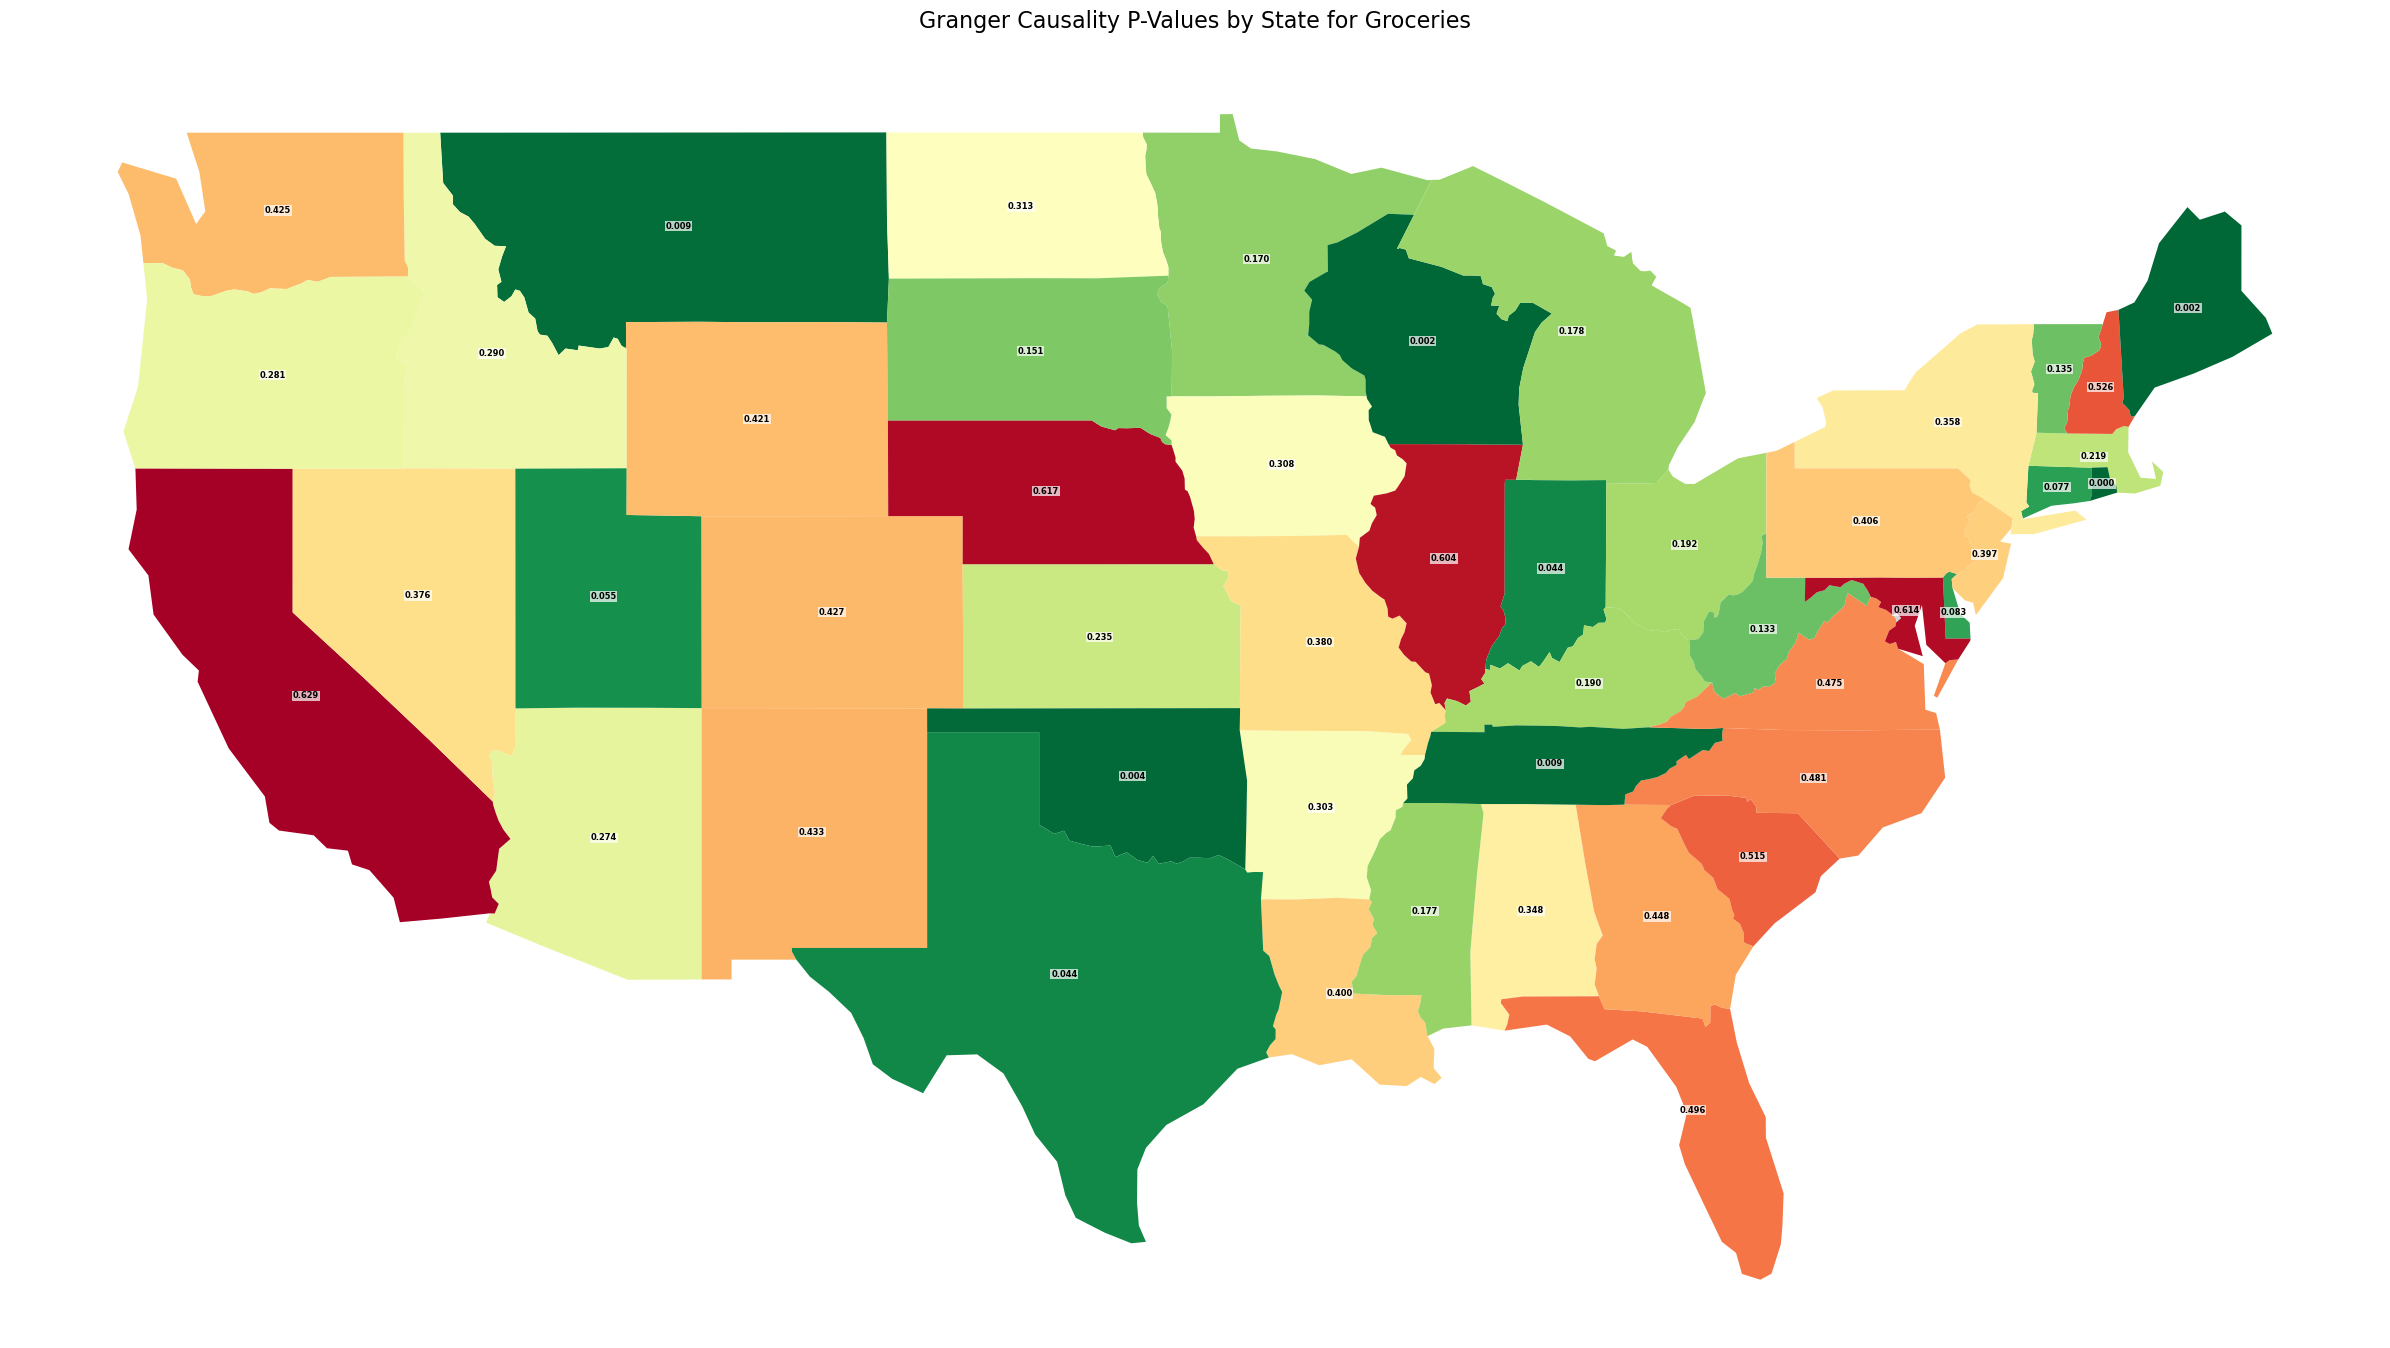

In [91]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_grocerie, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile - CORRECTED URL
# Replace the read_file line with:
usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  # Updated from 'STUSPS' to 'postal' which is the correct column name in current Natural Earth Data

# Rest of your code remains the same
usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.RdYlGn_r

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality P-Values by State for Groceries', fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

## Visualization Granger Test Fashion

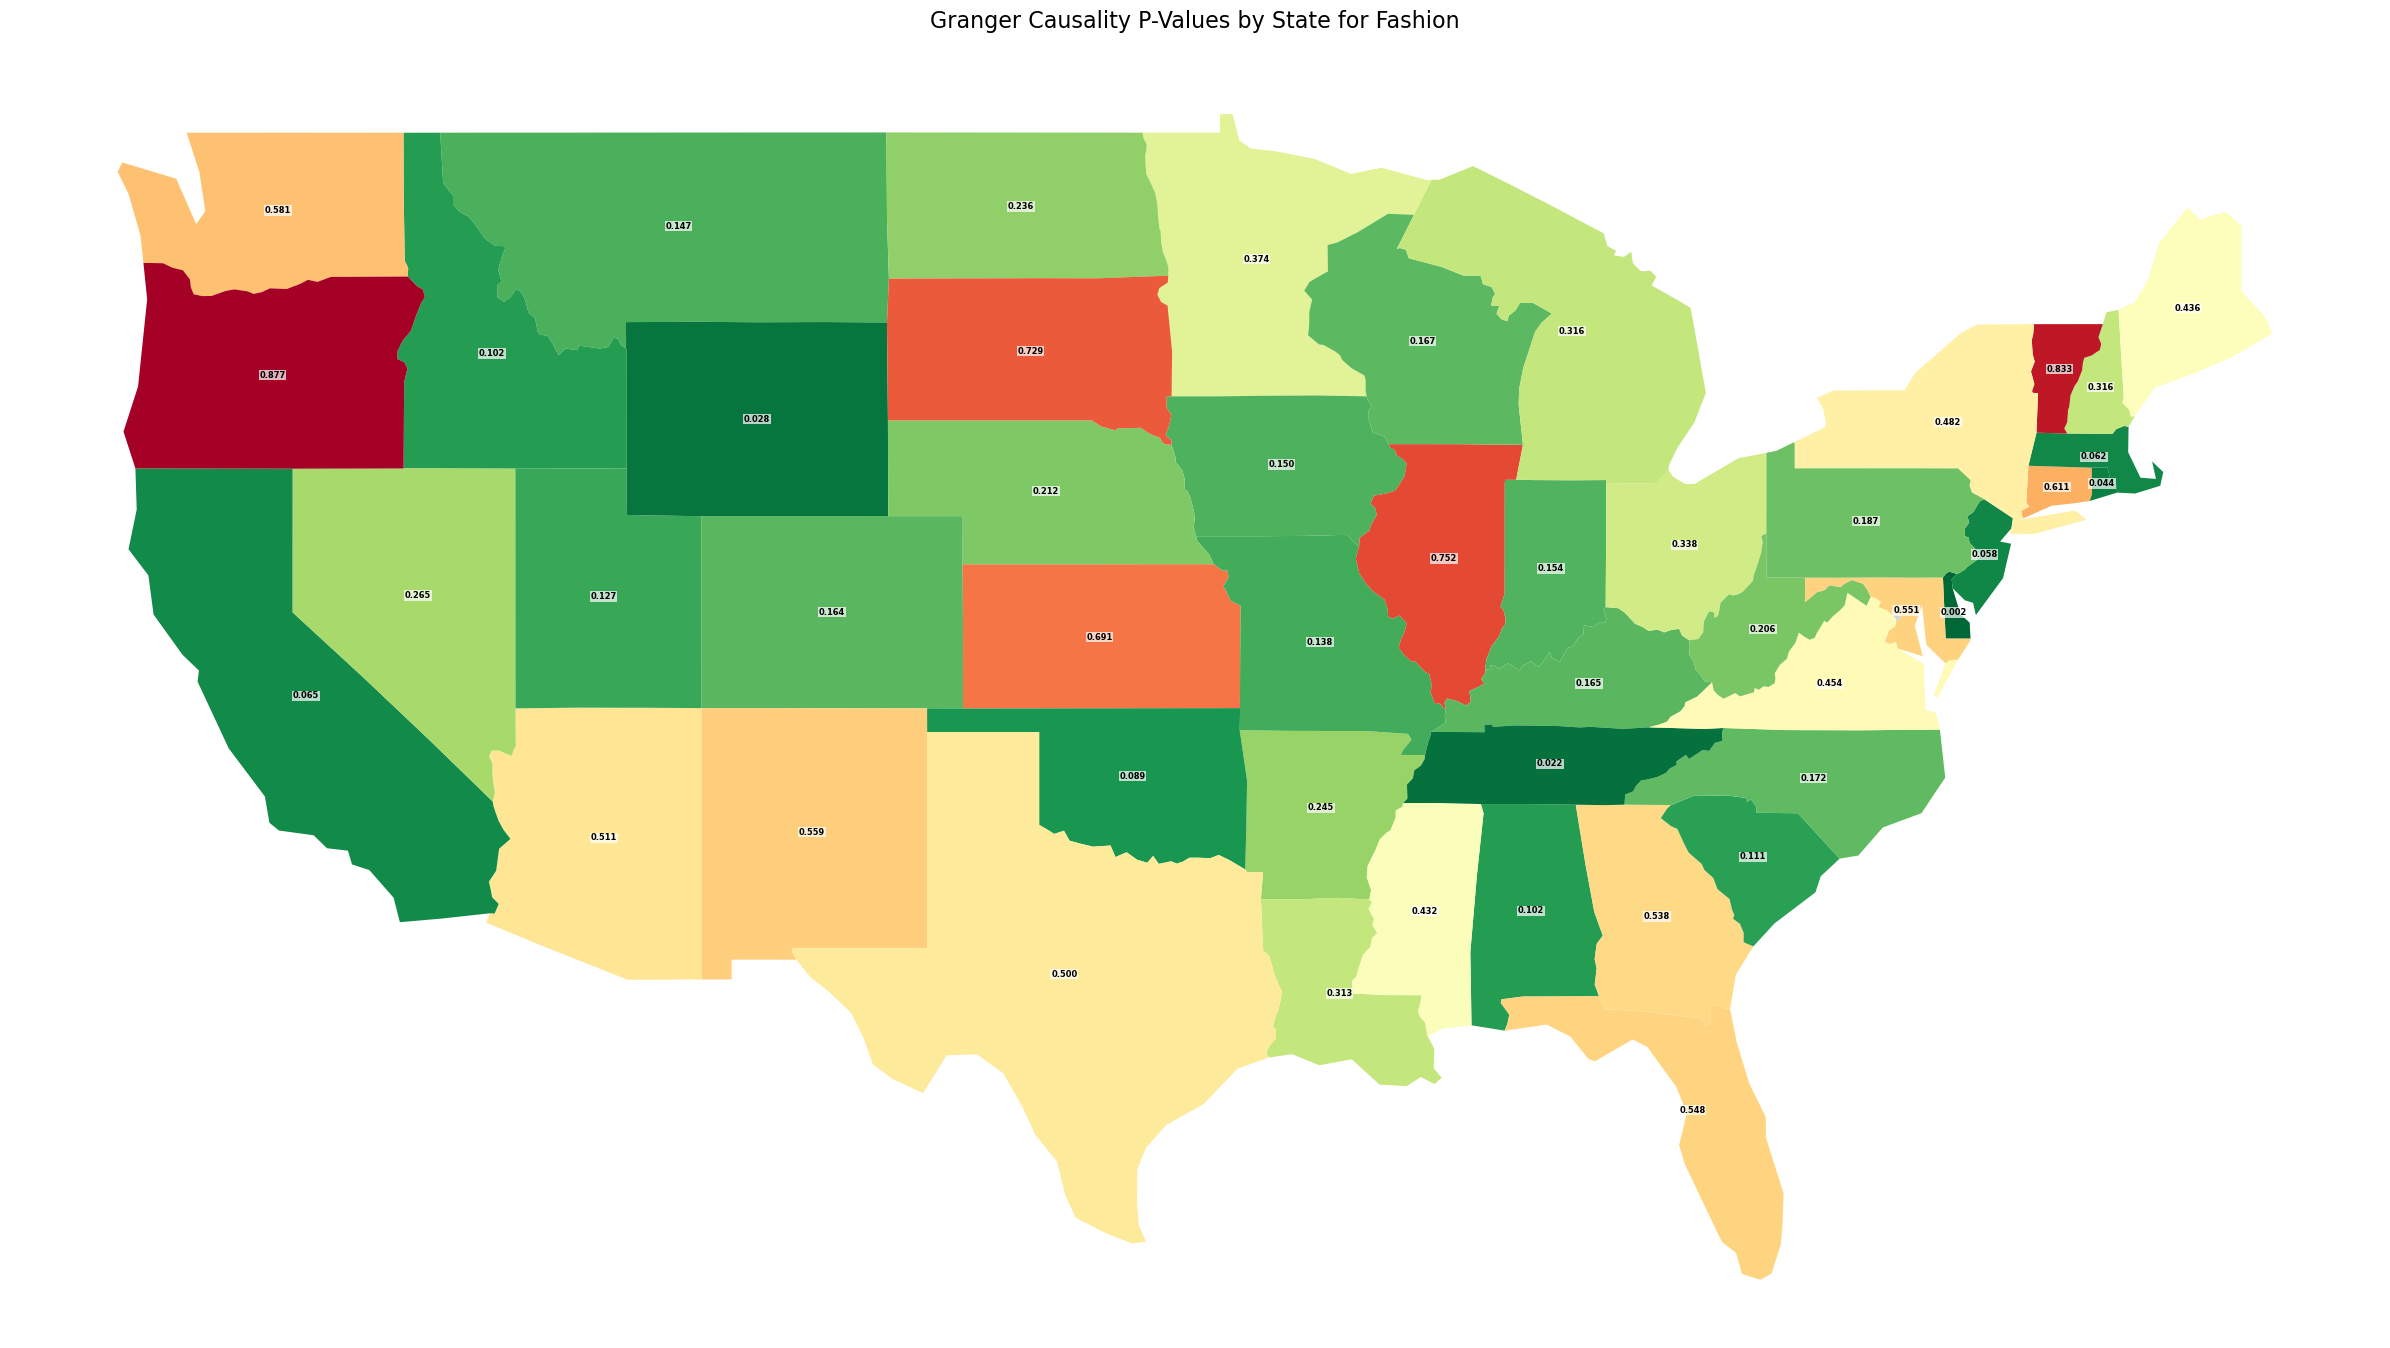

In [92]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values_fashion, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile - CORRECTED URL
# Replace the read_file line with:
usa = gpd.read_file('./data/Map_USA/ne_110m_admin_1_states_provinces.shp')
usa = usa[~usa['postal'].isin(['AK', 'HI'])]

# Convert state codes
usa['state'] = usa['postal']  # Updated from 'STUSPS' to 'postal' which is the correct column name in current Natural Earth Data

# Rest of your code remains the same
usa = usa.merge(p_value_df, on='state', how='left')

fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)
cmap = plt.cm.RdYlGn_r

usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title('Granger Causality P-Values by State for Fashion', fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Autocorrelation for first order Revenue lags

In [93]:
"""for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])"""

'for j in range(1,len(df_one_state)): \n            first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])'

In [94]:
series = df_one_state["first_order_diff_Revenue"]

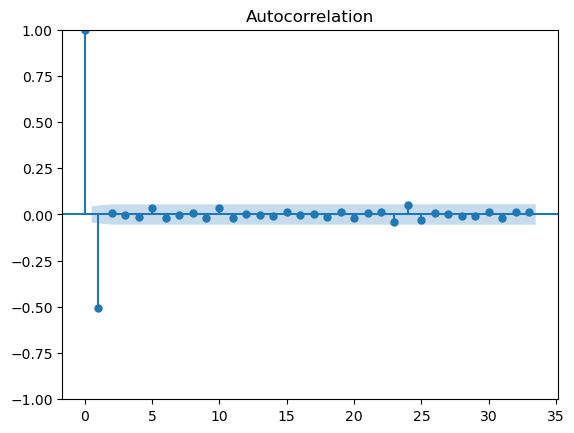

In [95]:
plot_acf(series)
plt.show()

#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/

Shows that if there was a purchase on t=0 it is less likley that someone is purchasing at t=1. Makes sense since when you bought something you are unlikley to buy something imeadiatly the next day. 

## Approach 2

In [96]:
import pandas as pd

# Take df of 
#1 subset 
#2 order 
#3 first order diff 
#4 Autocorrelation 


def autocorrelation_per_state(data): 
    states_list = data["Shipping Address State"].unique()
    results_df = pd.DataFrame(columns=['State', 't', 't+1','t+2','t+3','t+4','t+5','t+6'])

    for state in states_list: 
        # Filter for only one State
        state_filter = data["Shipping Address State"] == state # Create subset for only one state
        df_one_state = data[state_filter]

        # Order datapoints by date 
        df_one_state = df_one_state.sort_values("Order Date", ascending=True)

        # Calculate first order diff
        first_order_diff = [0]
        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])
        
        df_one_state["first_order_diff_Revenue"] = first_order_diff

        # Calculate autocorrelation
        series = df_one_state["first_order_diff_Revenue"]

        # using shift function to shift the values.
        dataframe = pd.concat([series.shift(6), series.shift(5), series.shift(4), series.shift(3), series.shift(2), series.shift(1), series], axis=1)
        # naming the columns
        dataframe.columns = ['t', 't+1', 't+2', 't+3', 't+4', 't+5', 't+6']

        # using corr() function to compute the correlation
        result = dataframe.corr()
        new_row = {"State": state, "t": result.iloc[0,0], "t+1": result.iloc[0,1], "t+2": result.iloc[0,2], "t+3": result.iloc[0,3], "t+4": result.iloc[0,4], "t+5": result.iloc[0,5], "t+6": result.iloc[0,6]}
        results_df.loc[len(results_df)] = new_row

    return results_df

### Fashion

In [97]:
#from utils.autocorrelation_per_state import autocorrelation_per_state

correlation_df = autocorrelation_per_state(fashion_df)
correlation_df.set_index('State', inplace=True)
correlation_df.head()

,t,t+1,t+2,t+3,t+4,t+5,t+6
State,,,,,,,
AL,1.0,-0.503654,0.002827,0.009869,-0.025171,0.033582,-0.031790
AR,1.0,-0.502067,0.014063,0.005458,-0.029363,0.025862,-0.045893
AZ,1.0,-0.515986,0.017966,0.004349,0.006319,-0.020023,0.005826
CA,1.0,-0.489015,0.009465,-0.051122,0.066014,-0.059265,0.026052
CO,1.0,-0.482796,-0.013490,0.001836,-0.005166,-0.008826,-0.006984


Text(95.72222222222221, 0.5, 'State')

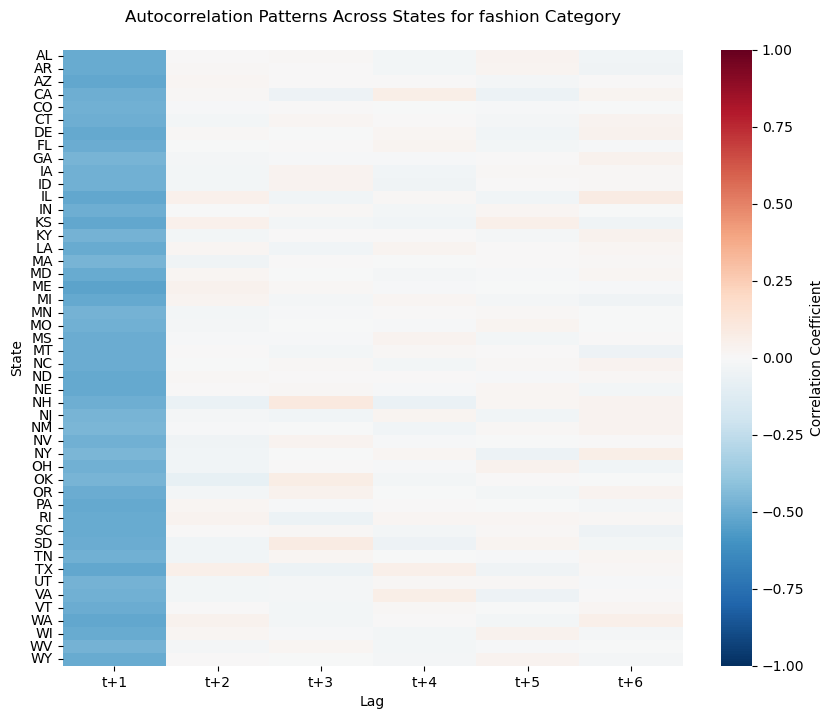

In [98]:
df_heatmap = correlation_df.iloc[:,1:] 

figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for fashion Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')

Basically there is only siginificant correlation between t and t+1

### Groceries

In [99]:
correlation_df = autocorrelation_per_state(groceries_df)
correlation_df.set_index('State', inplace=True)

Text(95.72222222222221, 0.5, 'State')

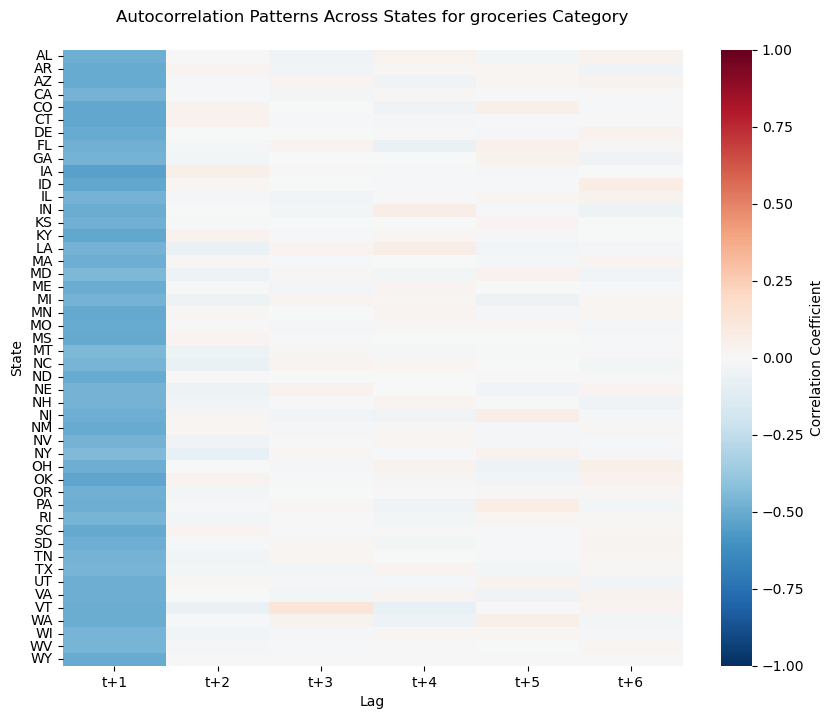

In [100]:
df_heatmap = correlation_df.iloc[:,1:] 
figsize=(10, 8) 
# Create figure and axes
plt.figure(figsize=figsize)

# Create heatmap
sns.heatmap(df_heatmap,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation value
            vmax=1,        # Maximum correlation value
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=True,
            yticklabels=True)

plt.title('Autocorrelation Patterns Across States for groceries Category', pad=20)
plt.xlabel('Lag')
plt.ylabel('State')